In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/water_dataX.csv', encoding='latin1')
df.head()


,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014


In [3]:
df.shape

(1991, 12)

In [4]:
df

,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014
...,...,...,...,...,...,...,...,...,...,...,...,...
1986,1330,"TAMBIRAPARANI AT ARUMUGANERI, TAMILNADU",NAN,NAN,7.9,738,7.2,2.7,0.518,0.518,202,2003
1987,1450,"PALAR AT VANIYAMBADI WATER SUPPLY HEAD WORK, T...",NAN,29,7.5,585,6.3,2.6,0.155,0.155,315,2003
1988,1403,"GUMTI AT U/S SOUTH TRIPURA,TRIPURA",NAN,28,7.6,98,6.2,1.2,NAN,NAN,570,2003
1989,1404,"GUMTI AT D/S SOUTH TRIPURA, TRIPURA",NAN,28,7.7,91,6.5,1.3,NAN,NAN,562,2003


In [5]:
df.isnull().sum()

,0
STATION CODE,0
LOCATIONS,0
STATE,0
Temp,0
D.O. (mg/l),0
PH,0
CONDUCTIVITY (µmhos/cm),0
B.O.D. (mg/l),0
NITRATENAN N+ NITRITENANN (mg/l),0
FECAL COLIFORM (MPN/100ml),0


In [6]:
# Replacing object/string values with actual null (NaN) values
import numpy as np

df.replace(["NAN", "NaN", "nan"], np.nan, inplace=True)

In [7]:
df.isnull().sum()

,0
STATION CODE,122
LOCATIONS,184
STATE,761
Temp,88
D.O. (mg/l),31
PH,8
CONDUCTIVITY (µmhos/cm),25
B.O.D. (mg/l),40
NITRATENAN N+ NITRITENANN (mg/l),220
FECAL COLIFORM (MPN/100ml),303


In [8]:
# Dropped since they don't matter for calculation of Water Quality Status
df.drop(columns=["STATION CODE", "LOCATIONS", "STATE", "year"], inplace=True)


In [9]:
# Converting every values in each columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [10]:
# Median is used because environmental data contains outliers that can distort the mean
df.fillna(df.median(numeric_only=True), inplace=True)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
features = [
    "PH",
    "D.O. (mg/l)",
    "B.O.D. (mg/l)",
    "TOTAL COLIFORM (MPN/100ml)Mean",
    "Temp"
]
corr_df = df[features]

In [12]:
correlation_matrix = corr_df.corr()
correlation_matrix

,PH,D.O. (mg/l),B.O.D. (mg/l),TOTAL COLIFORM (MPN/100ml)Mean,Temp
PH,1.000000,0.034607,0.041504,-0.001999,0.016685
D.O. (mg/l),0.034607,1.000000,-0.242991,-0.142605,0.026942
B.O.D. (mg/l),0.041504,-0.242991,1.000000,0.162955,-0.047709
TOTAL COLIFORM (MPN/100ml)Mean,-0.001999,-0.142605,0.162955,1.000000,0.008636
Temp,0.016685,0.026942,-0.047709,0.008636,1.000000


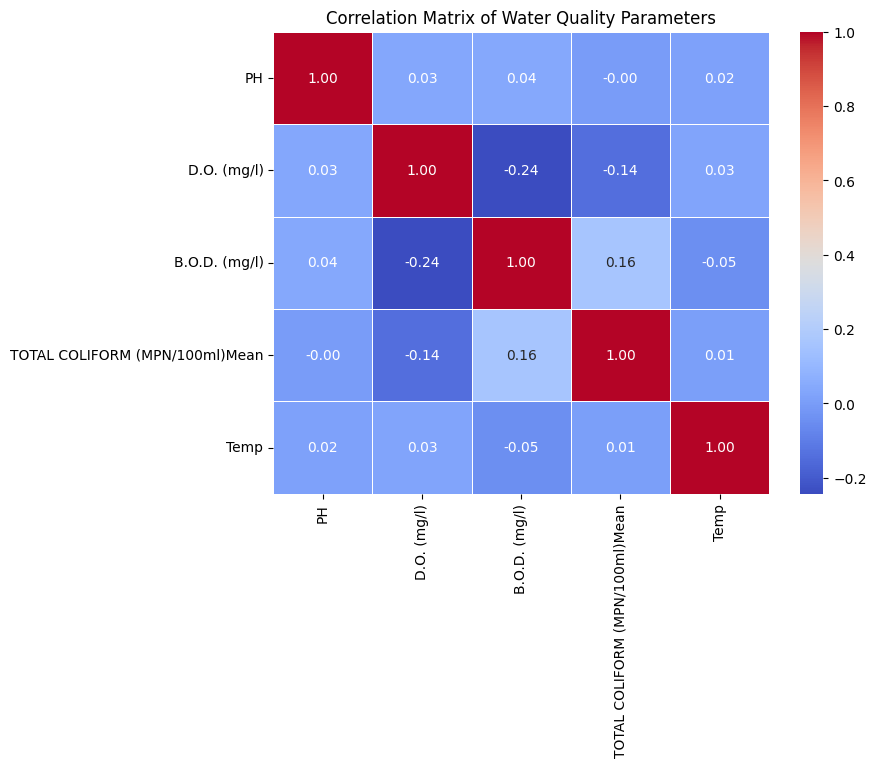

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Water Quality Parameters")
plt.show()


In [14]:
df.isnull().sum()

,0
Temp,0
D.O. (mg/l),0
PH,0
CONDUCTIVITY (µmhos/cm),0
B.O.D. (mg/l),0
NITRATENAN N+ NITRITENANN (mg/l),0
FECAL COLIFORM (MPN/100ml),0
TOTAL COLIFORM (MPN/100ml)Mean,0


In [15]:
# Creating the target column where the values meets the criteria based on CPCB(Central Pollution Control Board)
#
df["Water_Quality_Status"] = np.where(
    (df["TOTAL COLIFORM (MPN/100ml)Mean"] <= 50) &
    (df["PH"] >= 6.5) & (df["PH"] <= 8.5) &
    (df["D.O. (mg/l)"] >= 6) &
    (df["B.O.D. (mg/l)"] <= 2),
    0,   # Safe
    1    # Polluted
)

df["Water_Quality_Status"].value_counts()


,count
Water_Quality_Status,
1,1860
0,131


In [16]:
df

,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,Water_Quality_Status
0,30.6,6.7,7.5,203.0,1.8965,0.100,11.000,27.0,0
1,29.8,5.7,7.2,189.0,2.0000,0.200,4953.000,8391.0,1
2,29.5,6.3,6.9,179.0,1.7000,0.100,3243.000,5330.0,1
3,29.7,5.8,6.9,64.0,3.8000,0.500,5382.000,8443.0,1
4,29.5,5.8,7.3,83.0,1.9000,0.400,3428.000,5500.0,1
...,...,...,...,...,...,...,...,...,...
1986,27.0,7.9,738.0,7.2,2.7000,0.518,0.518,202.0,1
1987,29.0,7.5,585.0,6.3,2.6000,0.155,0.155,315.0,1
1988,28.0,7.6,98.0,6.2,1.2000,0.516,221.000,570.0,1
1989,28.0,7.7,91.0,6.5,1.3000,0.516,221.000,562.0,1


In [17]:
selected_features = [
    "PH",
    "D.O. (mg/l)",
    "B.O.D. (mg/l)",
    "TOTAL COLIFORM (MPN/100ml)Mean"
]
X = df[selected_features]
y = df["Water_Quality_Status"]


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Scaling is used since dataset has features with different ranges
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9348370927318296
              precision    recall  f1-score   support

           0       0.50      0.08      0.13        26
           1       0.94      0.99      0.97       373

    accuracy                           0.93       399
   macro avg       0.72      0.54      0.55       399
weighted avg       0.91      0.93      0.91       399



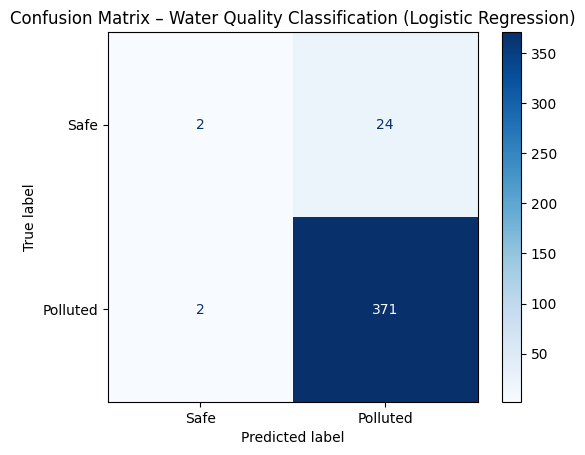

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)
labels = ["Safe", "Polluted"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Water Quality Classification (Logistic Regression)")
plt.show()



In [21]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9974937343358395
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        26
           1       1.00      1.00      1.00       373

    accuracy                           1.00       399
   macro avg       1.00      0.98      0.99       399
weighted avg       1.00      1.00      1.00       399



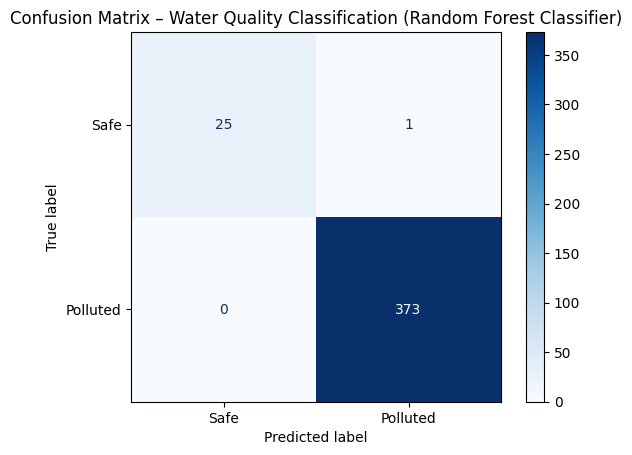

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)
labels = ["Safe", "Polluted"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Water Quality Classification (Random Forest Classifier)")
plt.show()

In [23]:
# To compare and finalize which Algorithm to choose
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison


,Model,Accuracy
0,Logistic Regression,0.934837
1,Random Forest,0.997494


In [24]:
df['Water_Quality_Status'].value_counts()

,count
Water_Quality_Status,
1,1860
0,131


In [25]:
import gradio as gr
import pandas as pd

def predict_water_quality(PH, DO, BOD, TotalColiform):
    # Check for None values and return an error message if any input is missing
    if any(arg is None for arg in [PH, DO, BOD, TotalColiform]):
        return "Please fill in all the water quality parameters.", ""

    # Create a DataFrame from the input values, ensuring correct column order
    input_data = pd.DataFrame([[
        PH,
        DO,
        BOD,
        TotalColiform
    ]], columns=X.columns)

    # Predict using the Random Forest model
    prediction = rf.predict(input_data)[0]

    violations = []

    if prediction == 0:
        return "Safe", "All parameters within CPCB safe limits."
    else:
        # Check CPCB criteria for 'Polluted' status if the model predicted 1
        if TotalColiform > 50:
            violations.append("Total Coliform > 50 (CPCB limit)")
        if not (6.5 <= PH <= 8.5):
            violations.append("pH out of CPCB range (6.5 - 8.5)")
        if DO < 6:
            violations.append("Dissolved Oxygen < 6 mg/l (CPCB limit)")
        if BOD > 2:
            violations.append("BOD > 2 mg/l (CPCB limit)")

        if violations:
            return "Polluted", "Reasons for Pollution: " + ", ".join(violations)
        else:
            # Fallback if model predicts polluted but no CPCB rule is directly violated by input
            return "Polluted", "Polluted based on model prediction; specific CPCB rule violations not met by input rules."

# --- Gradio Blocks Interface ---
with gr.Blocks() as demo:
    gr.Markdown("# Water Quality Prediction")
    gr.Markdown("Predict if water is safe or polluted based on input parameters.")

    with gr.Tab("Prediction Interface"):
        gr.Markdown("## Input Parameters")
        with gr.Row():
            ph_input = gr.Slider(minimum=0.0, maximum=14.0, value=7.0, step=0.1, label="pH (PH)")
            do_input = gr.Slider(minimum=0.0, maximum=20.0, value=7.0, step=0.1, label="Dissolved Oxygen (D.O. (mg/l))")
        with gr.Row():
            bod_input = gr.Slider(minimum=0.0, maximum=10.0, value=2.0, step=0.1, label="Biochemical Oxygen Demand (B.O.D. (mg/l))")
            total_coliform_input = gr.Slider(minimum=0, maximum=5000, value=50, step=10, label="Total Coliform (TOTAL COLIFORM (MPN/100ml)Mean)")

        predict_button = gr.Button("Predict Water Quality")
        output_textbox = gr.Textbox(label="Water Quality Status")
        pollution_reasons_textbox = gr.Textbox(label="Pollution Reasons", interactive=False)

        predict_button.click(
            fn=predict_water_quality,
            inputs=[
                ph_input,
                do_input,
                bod_input,
                total_coliform_input
            ],
            outputs=[output_textbox, pollution_reasons_textbox]
        )

#demo.launch(debug=True)